Dataset Preview
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   N

/tmp/ipykernel_1050/944406341.py:95: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(
/tmp/ipykernel_1050/944406341.py:101: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value},

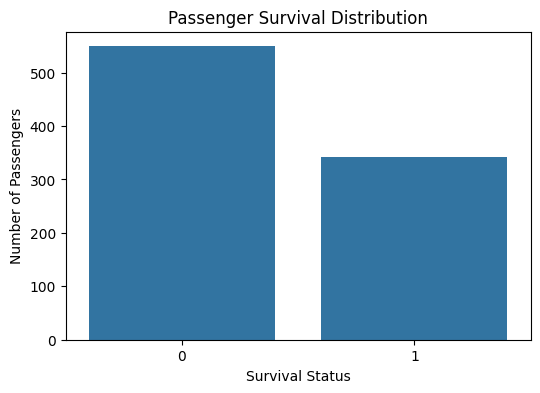

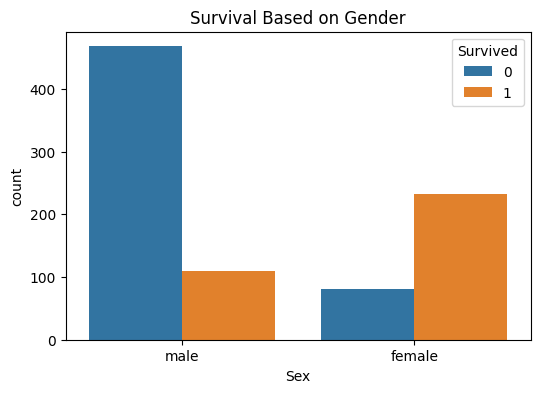

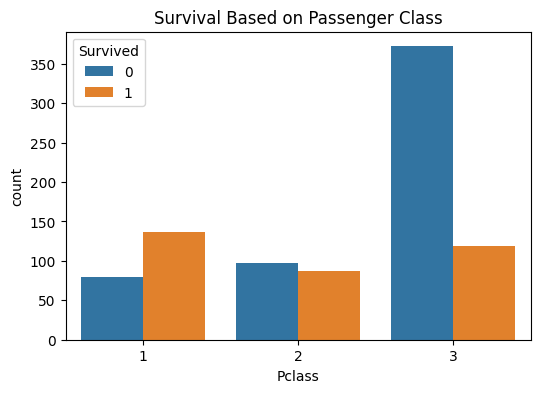

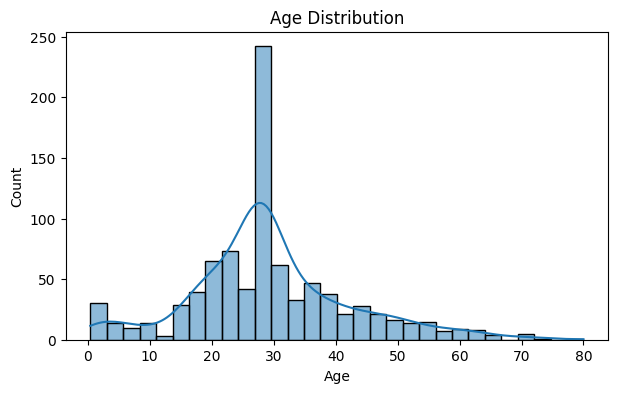

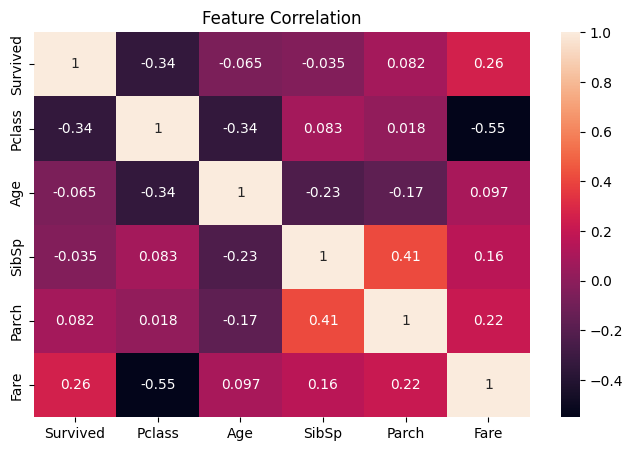


Chi-Square Test Result
-----------------------
Chi-square value: 260.71702016732104
P-value: 1.1973570627755645e-58
Reject Null Hypothesis: Gender affects survival

Model Performance
--------------------
Accuracy: 0.8044692737430168
Precision: 0.782608695652174
Recall: 0.7297297297297297
F1 Score: 0.7552447552447552

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



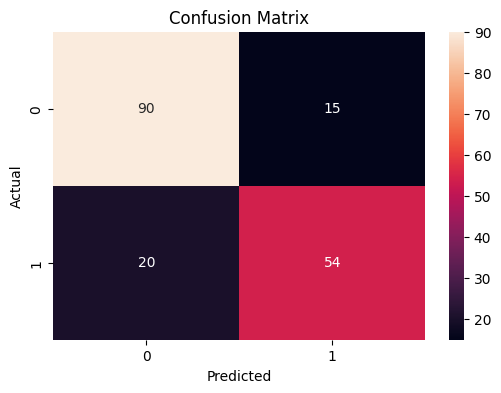

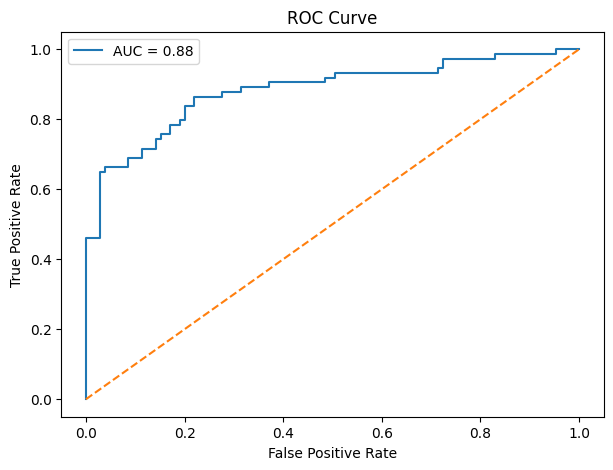


Feature Importance
    Feature  Coefficient
5      Fare     0.126216
4     Parch    -0.098292
6  Embarked    -0.170860
3     SibSp    -0.349582
2       Age    -0.395574
0    Pclass    -0.782061
1       Sex    -1.278865

PROJECT INSIGHTS
----------------

1. Gender strongly influenced survival probability.

2. Passenger class affected survival chances.

3. Higher class passengers had better survival rates.

4. Logistic Regression successfully predicted survival patterns.

5. Machine learning can support risk prediction and decision-making.



In [3]:
# ==========================================================
# NSDC Week 5 Final Project
# Titanic Survival Prediction: End-to-End Data Science Project
# ==========================================================


# ===============================
# 1. Import Libraries
# ===============================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


# Statistical Analysis

from scipy.stats import chi2_contingency


# Machine Learning

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler


from sklearn.linear_model import LogisticRegression


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)



# ===============================
# 2. Load Dataset
# ===============================


df = pd.read_csv("train.csv")


print("Dataset Preview")
print(df.head())


print("\nDataset Shape")
print(df.shape)


print("\nDataset Information")
print(df.info())


print("\nMissing Values")
print(df.isnull().sum())



# ===============================
# 3. Data Cleaning
# ===============================


# Remove unnecessary columns

df.drop(
    [
        "PassengerId",
        "Name",
        "Ticket",
        "Cabin"
    ],
    axis=1,
    inplace=True
)



# Fill missing values


df["Age"].fillna(
    df["Age"].median(),
    inplace=True
)


df["Embarked"].fillna(
    df["Embarked"].mode()[0],
    inplace=True
)



print("\nAfter Cleaning")

print(df.isnull().sum())



# ===============================
# 4. Exploratory Data Analysis
# ===============================



# Visualization 1
# Survival Count


plt.figure(figsize=(6,4))

sns.countplot(
    x="Survived",
    data=df
)

plt.title(
    "Passenger Survival Distribution"
)

plt.xlabel(
    "Survival Status"
)

plt.ylabel(
    "Number of Passengers"
)

plt.show()



# Visualization 2
# Gender Survival


plt.figure(figsize=(6,4))


sns.countplot(
    x="Sex",
    hue="Survived",
    data=df
)


plt.title(
    "Survival Based on Gender"
)


plt.show()



# Visualization 3
# Passenger Class


plt.figure(figsize=(6,4))


sns.countplot(
    x="Pclass",
    hue="Survived",
    data=df
)


plt.title(
    "Survival Based on Passenger Class"
)


plt.show()



# Visualization 4
# Age Distribution


plt.figure(figsize=(7,4))


sns.histplot(
    df["Age"],
    bins=30,
    kde=True
)


plt.title(
    "Age Distribution"
)


plt.show()



# Visualization 5
# Correlation Heatmap


plt.figure(figsize=(8,5))


sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)


plt.title(
    "Feature Correlation"
)


plt.show()



# ===============================
# 5. Statistical Hypothesis Testing
# ===============================


# Hypothesis:
# Gender affects survival


contingency_table = pd.crosstab(
    df["Sex"],
    df["Survived"]
)


chi2, p_value, dof, expected = chi2_contingency(
    contingency_table
)


print("\nChi-Square Test Result")

print("-----------------------")

print(
    "Chi-square value:",
    chi2
)

print(
    "P-value:",
    p_value
)



if p_value < 0.05:

    print(
        "Reject Null Hypothesis: Gender affects survival"
    )

else:

    print(
        "Accept Null Hypothesis: Gender does not affect survival"
    )



# ===============================
# 6. Data Preprocessing
# ===============================



# Convert categorical columns


encoder = LabelEncoder()


df["Sex"] = encoder.fit_transform(
    df["Sex"]
)


df["Embarked"] = encoder.fit_transform(
    df["Embarked"]
)



# ===============================
# 7. Feature and Target Split
# ===============================



X = df.drop(
    "Survived",
    axis=1
)


y = df["Survived"]



# Train Test Split


X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42

)



# ===============================
# 8. Feature Scaling
# ===============================



scaler = StandardScaler()


X_train = scaler.fit_transform(
    X_train
)


X_test = scaler.transform(
    X_test
)



# ===============================
# 9. Machine Learning Model
# ===============================


# Logistic Regression


model = LogisticRegression()


model.fit(
    X_train,
    y_train
)



# Prediction


y_pred = model.predict(
    X_test
)



# ===============================
# 10. Model Evaluation
# ===============================



accuracy = accuracy_score(
    y_test,
    y_pred
)


precision = precision_score(
    y_test,
    y_pred
)


recall = recall_score(
    y_test,
    y_pred
)


f1 = f1_score(
    y_test,
    y_pred
)



print("\nModel Performance")

print("--------------------")


print(
    "Accuracy:",
    accuracy
)


print(
    "Precision:",
    precision
)


print(
    "Recall:",
    recall
)


print(
    "F1 Score:",
    f1
)



print("\nClassification Report")

print(
    classification_report(
        y_test,
        y_pred
    )
)



# ===============================
# 11. Confusion Matrix
# ===============================



cm = confusion_matrix(
    y_test,
    y_pred
)


plt.figure(figsize=(6,4))


sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)


plt.xlabel(
    "Predicted"
)


plt.ylabel(
    "Actual"
)


plt.title(
    "Confusion Matrix"
)


plt.show()



# ===============================
# 12. ROC Curve
# ===============================



probability = model.predict_proba(
    X_test
)[:,1]


fpr, tpr, threshold = roc_curve(
    y_test,
    probability
)


roc_auc = auc(
    fpr,
    tpr
)



plt.figure(figsize=(7,5))


plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.2f}"
)


plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)


plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.title(
    "ROC Curve"
)


plt.legend()


plt.show()



# ===============================
# 13. Feature Importance
# ===============================



importance = pd.DataFrame({

    "Feature": X.columns,

    "Coefficient": model.coef_[0]

})


importance.sort_values(
    by="Coefficient",
    ascending=False,
    inplace=True
)



print("\nFeature Importance")

print(importance)



# ===============================
# 14. Final Insights
# ===============================


print("\nPROJECT INSIGHTS")

print("----------------")

print("""
1. Gender strongly influenced survival probability.

2. Passenger class affected survival chances.

3. Higher class passengers had better survival rates.

4. Logistic Regression successfully predicted survival patterns.

5. Machine learning can support risk prediction and decision-making.
""")